In [ ]:
# 读取所有子表并合并为大表，导出 CSV（跳过“说明”，去第二行单位；用 年/月/日/时/分 合成 date，保留其余列）
import pandas as pd
import numpy as np
from pathlib import Path

# 尝试定位 Excel 文件：优先同目录文件名，找不到则全局搜索
base_dir = Path('.').resolve()
excel_name = '气象数据_多伦_2006-2015.xlsx'
excel_path = base_dir / excel_name
if not excel_path.exists():
    matches = list(base_dir.rglob(excel_name))
    if len(matches):
        excel_path = matches[0]
    else:
        raise FileNotFoundError(f'未找到 {excel_name}，请将文件放在 Notebook 同目录或提供路径。当前目录: {base_dir}')

print('使用文件:', excel_path)

# 读取所有子表（跳过“说明”）
xls = pd.ExcelFile(excel_path)
sheet_names = [s for s in xls.sheet_names if s != '说明']
print('处理子表数量:', len(sheet_names), sheet_names)

frames = []
for sh in sheet_names:
    df = pd.read_excel(xls, sheet_name=sh)

    # 去掉第二行（单位行）：首行表头、第二行单位
    if len(df) >= 1:
        df = df.iloc[1:].reset_index(drop=True)

    # 标准化列名
    df.columns = [str(c).strip().replace('\u3000', ' ') for c in df.columns]

    # 确保时间组件列存在
    time_cols = ['年', '月', '日']
    if not all(c in df.columns for c in time_cols):
        print(f'子表 {sh} 缺少 年/月/日，已跳过。现有列示例: {list(df.columns)[:12]}')
        continue
    if '时' not in df.columns:
        df['时'] = 0
    if '分' not in df.columns:
        df['分'] = 0

    # 转为数值并填充
    for c in ['年', '月', '日', '时', '分']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df['时'] = df['时'].fillna(0)
    df['分'] = df['分'].fillna(0)

    # 生成 date 列
    dt = pd.to_datetime(
        {
            'year': df['年'],
            'month': df['月'],
            'day': df['日'],
            'hour': df['时'],
            'minute': df['分'],
        },
        errors='coerce'
    )

    # 删除时间组件列，插入 date 为首列，保留其余原始列
    keep_other = [c for c in df.columns if c not in ['年', '月', '日', '时', '分']]
    out = pd.concat([pd.DataFrame({'date': dt}), df[keep_other]], axis=1)

    # 丢弃无效时间
    out = out.dropna(subset=['date']).reset_index(drop=True)

    frames.append(out)

if not frames:
    raise ValueError('没有可用的数据表（缺少 年/月/日）。')

merged = pd.concat(frames, ignore_index=True)
merged = merged.sort_values('date').reset_index(drop=True)

# # 导出目录
# out_dir = base_dir / '分析输出'
# out_dir.mkdir(parents=True, exist_ok=True)

# out_csv = out_dir / 'DuoLun_merged.csv'
# merged.to_csv(out_csv.as_posix(), index=False)
# print('已导出 CSV:', out_csv, 'shape=', merged.shape)


已导出 CSV: /sda/home/wangmengyao/timexer/data_process/多伦/分析输出/DuoLun_merged.csv shape= (175296, 17)


In [8]:
# 汇总通量表：合并所有工作表（跳过“说明”），仅用 年月日时分 + NEE/LE/H，生成 date 并导出
import pandas as pd
import numpy as np
from pathlib import Path

base_dir = Path('.').resolve()

# 1) 定位通量工作簿：优先同目录匹配 *通量*.xlsx，找不到则报错
candidates = list(base_dir.glob('*通量*.xlsx'))
if not candidates:
    raise FileNotFoundError('未找到通量工作簿（请将文件命名含“通量”，放在本Notebook同目录）。')
flux_xlsx = candidates[0]
print('使用通量文件:', flux_xlsx)

# 2) 需要的列（原表就有这些列）
need_cols = ['年', '月', '日', '时', '分', 'NEE', 'LE', 'H']

# 3) 读取各子表（跳过“说明”），去掉第二行单位，只保留需要的列
xls = pd.ExcelFile(flux_xlsx)
sheet_names = [s for s in xls.sheet_names if s != '说明']
print('处理子表数量:', len(sheet_names), sheet_names)

frames = []
for sh in sheet_names:
    df = pd.read_excel(xls, sheet_name=sh)
    # 去掉第二行（单位行）：首行表头、第二行单位
    if len(df) >= 1:
        df = df.iloc[1:].reset_index(drop=True)
    # 统一列名去空格
    df.columns = [str(c).strip() for c in df.columns]
    # 只保留需要的列（存在的部分）
    keep = [c for c in need_cols if c in df.columns]
    if len(keep) < 5:  # 年月日时分至少5个都应存在
        print(f'子表 {sh} 缺少必要时间列，已跳过。现有列: {list(df.columns)[:10]} ...')
        continue
    df = df[keep]

    # 数值化 年月日时分
    for c in ['年', '月', '日', '时', '分']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    # 缺失的小时/分钟填0
    df['时'] = df['时'].fillna(0)
    df['分'] = df['分'].fillna(0)

    # 生成 date
    dt = pd.to_datetime({
        'year': df['年'],
        'month': df['月'],
        'day': df['日'],
        'hour': df['时'],
        'minute': df['分'],
    }, errors='coerce')
    df.insert(0, 'date', dt)

    # 剩余列：date + NEE/LE/H（若存在）
    val_cols = [c for c in ['NEE', 'LE', 'H'] if c in df.columns]
    df = df[['date'] + val_cols]
    # 丢弃无效时间行
    df = df.dropna(subset=['date']).reset_index(drop=True)

    frames.append(df)

if not frames:
    raise ValueError('没有可用的通量数据，请检查表结构是否包含 年月日时分 与 NEE/LE/H。')

flux = pd.concat(frames, ignore_index=True)
flux = flux.sort_values('date').reset_index(drop=True)

# 4) 导出：date放首列
out_dir = base_dir / '分析输出'
out_dir.mkdir(parents=True, exist_ok=True)
flux_out = out_dir / 'DuoLun_flux_merged.csv'
flux.to_csv(flux_out.as_posix(), index=False)
print('已导出通量汇总 CSV:', flux_out, 'shape=', flux.shape)


使用通量文件: /sda/home/wangmengyao/timexer/data_process/多伦/碳水通量数据_多伦_2006-2015.xlsx
处理子表数量: 10 ['2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']
已导出通量汇总 CSV: /sda/home/wangmengyao/timexer/data_process/多伦/分析输出/DuoLun_flux_merged.csv shape= (175296, 4)


In [9]:
# 预览：打印气象表与通量表前五行
import pandas as pd
from pathlib import Path

base_dir = Path('.').resolve()
met_csv = base_dir / '分析输出' / 'DuoLun_merged.csv'
flux_csv = base_dir / '分析输出' / 'DuoLun_flux_merged.csv'

if not met_csv.exists():
    print('未找到气象表 CSV:', met_csv, '\n请先运行上方“气象合并”单元生成该文件。')
else:
    met = pd.read_csv(met_csv, parse_dates=['date'])
    print('气象表文件:', met_csv)
    print('形状:', met.shape)
    display(met.head(5))

if not flux_csv.exists():
    print('未找到通量表 CSV:', flux_csv, '\n请先运行上方“通量合并”单元生成该文件。')
else:
    flux = pd.read_csv(flux_csv, parse_dates=['date'])
    print('通量表文件:', flux_csv)
    print('形状:', flux.shape)
    display(flux.head(5))


气象表文件: /sda/home/wangmengyao/timexer/data_process/多伦/分析输出/DuoLun_merged.csv
形状: (175296, 17)


/tmp/ipykernel_83426/2186029995.py:12: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  met = pd.read_csv(met_csv, parse_dates=['date'])


,date,SWin,SWout,LWin,LWout,Rn,G,PAR,Ta,RH,Rainfall,Ts,SWC,WS,WD,Ustar,PA
0,2006-01-01 00:00:00,-2.30328,0.838569,172.833,256.909,-87.2177,-4.987333,-0.177842,-9.52959,76.4537,0.0,-7.729,0.038,4.96801,312.374,0.389470,85.6218
1,2006-01-01 00:30:00,-2.22890,1.037520,172.688,255.640,-86.2181,-5.918667,-0.174664,-9.55552,75.5225,0.0,-7.802,0.038,4.56082,322.732,0.329278,85.6334
2,2006-01-01 01:00:00,-2.24978,0.964466,171.847,254.407,-85.7744,-6.616000,-0.179164,-9.76438,74.7686,0.0,-7.879,0.038,4.54027,319.055,0.321958,85.6444
3,2006-01-01 01:30:00,-2.42592,0.686394,169.049,252.103,-86.1669,-7.011667,-0.177526,-10.65380,76.2375,0.0,-7.961,0.038,4.86875,310.059,0.322772,85.6402
4,2006-01-01 02:00:00,-3.28989,0.195798,166.748,241.106,-77.8439,-7.523000,-0.206410,-12.44440,78.8450,0.0,-8.050,0.038,2.75684,288.643,0.293658,85.6722


通量表文件: /sda/home/wangmengyao/timexer/data_process/多伦/分析输出/DuoLun_flux_merged.csv
形状: (175296, 4)


,date,NEE,LE,H
0,2006-01-01 00:00:00,0.005543,-4.268417,-37.748853
1,2006-01-01 00:30:00,0.011973,-7.864132,-45.037713
2,2006-01-01 01:00:00,0.019363,-8.011240,-42.338457
3,2006-01-01 01:30:00,0.015838,-7.716699,-47.107299
4,2006-01-01 02:00:00,0.009041,-5.027285,-32.367593


In [10]:
# 对齐：先从通量表去掉 LE/H，再与气象表按 date 精确对齐，并移除指定气象列
import pandas as pd
from pathlib import Path

base_dir = Path('.').resolve()
met_csv = base_dir / '分析输出' / 'DuoLun_merged.csv'
flux_csv = base_dir / '分析输出' / 'DuoLun_flux_merged.csv'

# 读取两表
met = pd.read_csv(met_csv, parse_dates=['date'])
flux = pd.read_csv(flux_csv, parse_dates=['date'])
print('原始形状 -> met:', met.shape, 'flux:', flux.shape)

# 去掉气象表中不需要的列（若存在）：SWin, LWin, LWout, G, PAR, Rainfall
cols_to_drop = ['SWin', 'LWin', 'LWout', 'G', 'PAR', 'Rainfall']
drop_in_met = [c for c in cols_to_drop if c in met.columns]
if drop_in_met:
    met = met.drop(columns=drop_in_met, errors='ignore')
    print('已从气象表移除列:', drop_in_met)

# 去掉通量表的 LE 和 H 两列（若存在）
flux = flux.drop(columns=[c for c in ['LE', 'H'] if c in flux.columns], errors='ignore')

# 按 date 精确对齐（内连接，仅保留共同时间戳）
aligned = pd.merge(met, flux, on='date', how='inner', suffixes=('_met', '_flux'))
print('对齐后形状:', aligned.shape)

# 导出
out_aligned = base_dir / '分析输出' / 'DuoLun_met_flux_aligned.csv'
aligned.to_csv(out_aligned.as_posix(), index=False)
print('已导出对齐后的 CSV:', out_aligned)

# 预览前五行
display(met.head(5))
display(flux.head(5))
display(aligned.head(5))


/tmp/ipykernel_83426/3498198875.py:10: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  met = pd.read_csv(met_csv, parse_dates=['date'])


原始形状 -> met: (175296, 17) flux: (175296, 4)
已从气象表移除列: ['SWin', 'LWin', 'LWout', 'G', 'PAR', 'Rainfall']
对齐后形状: (175296, 12)
已导出对齐后的 CSV: /sda/home/wangmengyao/timexer/data_process/多伦/分析输出/DuoLun_met_flux_aligned.csv


,date,SWout,Rn,Ta,RH,Ts,SWC,WS,WD,Ustar,PA
0,2006-01-01 00:00:00,0.838569,-87.2177,-9.52959,76.4537,-7.729,0.038,4.96801,312.374,0.389470,85.6218
1,2006-01-01 00:30:00,1.037520,-86.2181,-9.55552,75.5225,-7.802,0.038,4.56082,322.732,0.329278,85.6334
2,2006-01-01 01:00:00,0.964466,-85.7744,-9.76438,74.7686,-7.879,0.038,4.54027,319.055,0.321958,85.6444
3,2006-01-01 01:30:00,0.686394,-86.1669,-10.65380,76.2375,-7.961,0.038,4.86875,310.059,0.322772,85.6402
4,2006-01-01 02:00:00,0.195798,-77.8439,-12.44440,78.8450,-8.050,0.038,2.75684,288.643,0.293658,85.6722


,date,NEE
0,2006-01-01 00:00:00,0.005543
1,2006-01-01 00:30:00,0.011973
2,2006-01-01 01:00:00,0.019363
3,2006-01-01 01:30:00,0.015838
4,2006-01-01 02:00:00,0.009041


,date,SWout,Rn,Ta,RH,Ts,SWC,WS,WD,Ustar,PA,NEE
0,2006-01-01 00:00:00,0.838569,-87.2177,-9.52959,76.4537,-7.729,0.038,4.96801,312.374,0.389470,85.6218,0.005543
1,2006-01-01 00:30:00,1.037520,-86.2181,-9.55552,75.5225,-7.802,0.038,4.56082,322.732,0.329278,85.6334,0.011973
2,2006-01-01 01:00:00,0.964466,-85.7744,-9.76438,74.7686,-7.879,0.038,4.54027,319.055,0.321958,85.6444,0.019363
3,2006-01-01 01:30:00,0.686394,-86.1669,-10.65380,76.2375,-7.961,0.038,4.86875,310.059,0.322772,85.6402,0.015838
4,2006-01-01 02:00:00,0.195798,-77.8439,-12.44440,78.8450,-8.050,0.038,2.75684,288.643,0.293658,85.6722,0.009041


Train/Test shapes: (140236, 9) (35060, 9)
MAE=0.0323 MSE=0.0042 RMSE=0.0649 R2=0.6589
已保存预测到: /sda/home/wangmengyao/timexer/data_process/多伦/分析输出/DuoLun_rf_predictions.csv


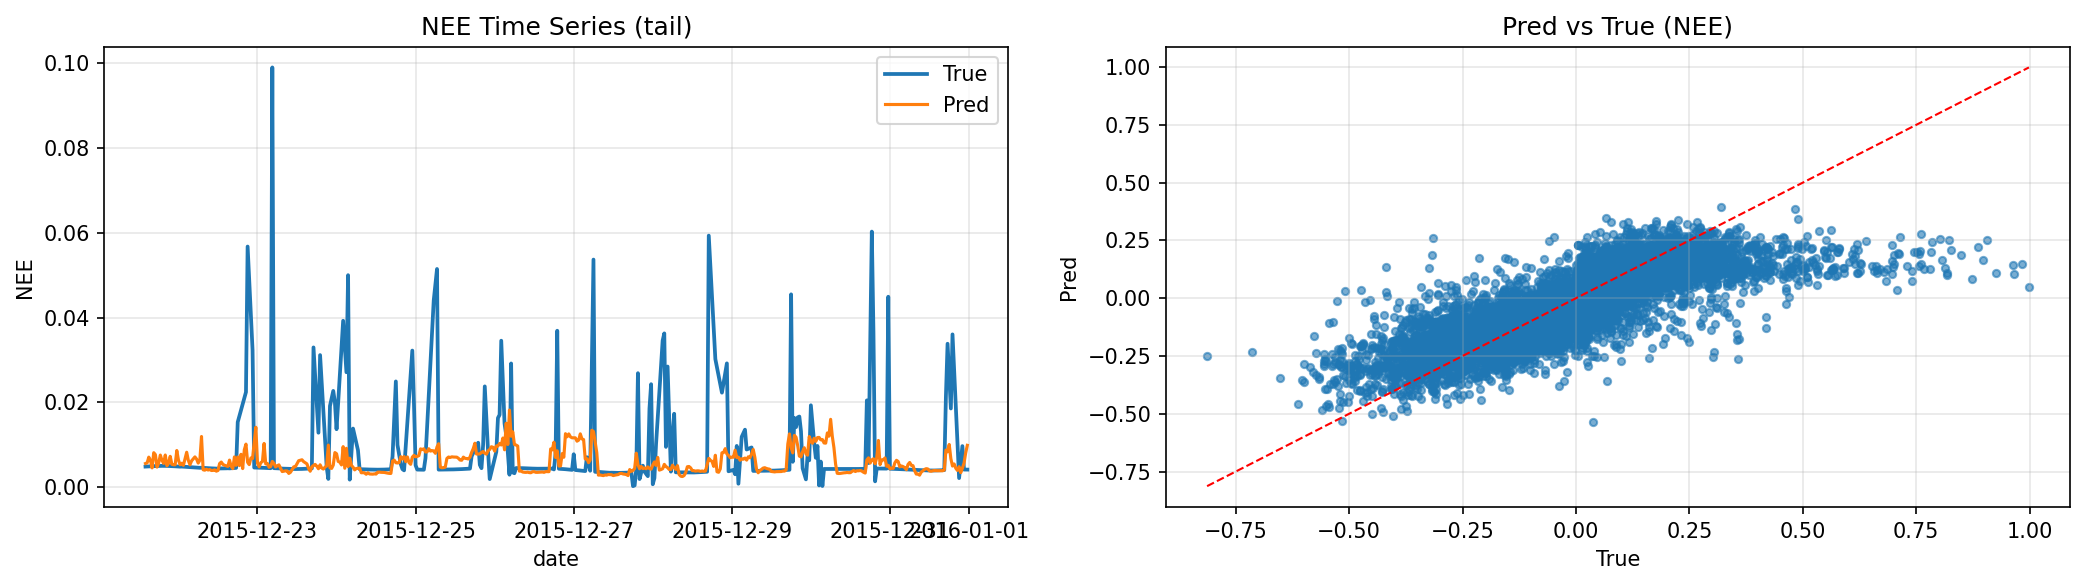

In [11]:
# 随机森林回归：以 NEE 为目标，基于对齐后的特征训练与评估
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

base_dir = Path('.').resolve()
aligned_csv = base_dir / '分析输出' / 'DuoLun_met_flux_aligned.csv'
met_csv = base_dir / '分析输出' / 'DuoLun_merged.csv'
flux_csv = base_dir / '分析输出' / 'DuoLun_flux_merged.csv'

# 若对齐文件不存在，则现场按 date 内连接生成一个
if not aligned_csv.exists():
    assert met_csv.exists() and flux_csv.exists(), '缺少对齐文件且未找到原始CSV，请先运行上方合并/对齐单元。'
    met = pd.read_csv(met_csv, parse_dates=['date'])
    flux = pd.read_csv(flux_csv, parse_dates=['date'])
    # 去掉通量表 LE/H（若存在）
    flux = flux.drop(columns=[c for c in ['LE', 'H'] if c in flux.columns], errors='ignore')
    df = pd.merge(met, flux, on='date', how='inner', suffixes=('_met', '_flux'))
else:
    df = pd.read_csv(aligned_csv, parse_dates=['date'])

# 目标列：NEE（若列名不同，尝试候选）
target_candidates = ['NEE', 'NEE_flux', 'flux_NEE']
target_col = None
for c in target_candidates:
    if c in df.columns:
        target_col = c
        break
assert target_col is not None, f"未找到目标列 NEE（候选: {target_candidates}）"

# 排序并时间切分（避免泄漏）：80% 训练，20% 测试
df = df.sort_values('date').reset_index(drop=True)
# 特征：所有数值列，去除目标和明显不应作为特征的列
drop_feature_cols = [target_col, 'LE', 'H', 'LE_flux', 'H_flux']
num_df = df.select_dtypes(include=[np.number]).copy()
X = num_df.drop(columns=[c for c in drop_feature_cols if c in num_df.columns], errors='ignore')
y = df[target_col].astype(float)

# 去掉 y 为 NaN 的样本
mask = ~np.isnan(y.values)
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)
dates = df.loc[mask, 'date'].reset_index(drop=True)

# 简单缺失填充：以列中位数填充
X = X.fillna(X.median(numeric_only=True))

n = len(X)
split = int(n * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
d_test = dates.iloc[split:]

print('Train/Test shapes:', X_train.shape, X_test.shape)

# 训练随机森林
rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1, max_depth=None)
rf.fit(X_train, y_train)

# 预测与评估
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'MAE={mae:.4f} MSE={mse:.4f} RMSE={rmse:.4f} R2={r2:.4f}')

# 保存预测结果
out_pred = pd.DataFrame({
    'date': d_test,
    'NEE_true': y_test.values,
    'NEE_pred': y_pred,
})
pred_path = base_dir / '分析输出' / 'DuoLun_rf_predictions.csv'
out_pred.to_csv(pred_path.as_posix(), index=False)
print('已保存预测到:', pred_path)

# 可视化：时间序列（末尾500点）与散点
tail_n = min(500, len(out_pred))
fig, axs = plt.subplots(1, 2, figsize=(14, 4), dpi=150)
axs[0].plot(out_pred['date'].iloc[-tail_n:], out_pred['NEE_true'].iloc[-tail_n:], label='True', linewidth=1.8)
axs[0].plot(out_pred['date'].iloc[-tail_n:], out_pred['NEE_pred'].iloc[-tail_n:], label='Pred', linewidth=1.5)
axs[0].set_title('NEE Time Series (tail)')
axs[0].set_xlabel('date')
axs[0].set_ylabel('NEE')
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].scatter(out_pred['NEE_true'], out_pred['NEE_pred'], s=12, alpha=0.6)
mn = float(min(out_pred['NEE_true'].min(), out_pred['NEE_pred'].min()))
mx = float(max(out_pred['NEE_true'].max(), out_pred['NEE_pred'].max()))
axs[1].plot([mn, mx], [mn, mx], 'r--', linewidth=1)
axs[1].set_title('Pred vs True (NEE)')
axs[1].set_xlabel('True')
axs[1].set_ylabel('Pred')
axs[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


使用数据集: aligned 
文件: /sda/home/wangmengyao/timexer/data_process/多伦/分析输出/DuoLun_met_flux_aligned.csv
数值列数量: 10
已导出相关性矩阵 CSV: /sda/home/wangmengyao/timexer/data_process/多伦/分析输出/corr_aligned_pearson.csv shape= (10, 10)
已保存热力图: /sda/home/wangmengyao/timexer/data_process/多伦/分析输出/corr_heatmap_aligned_pearson.png


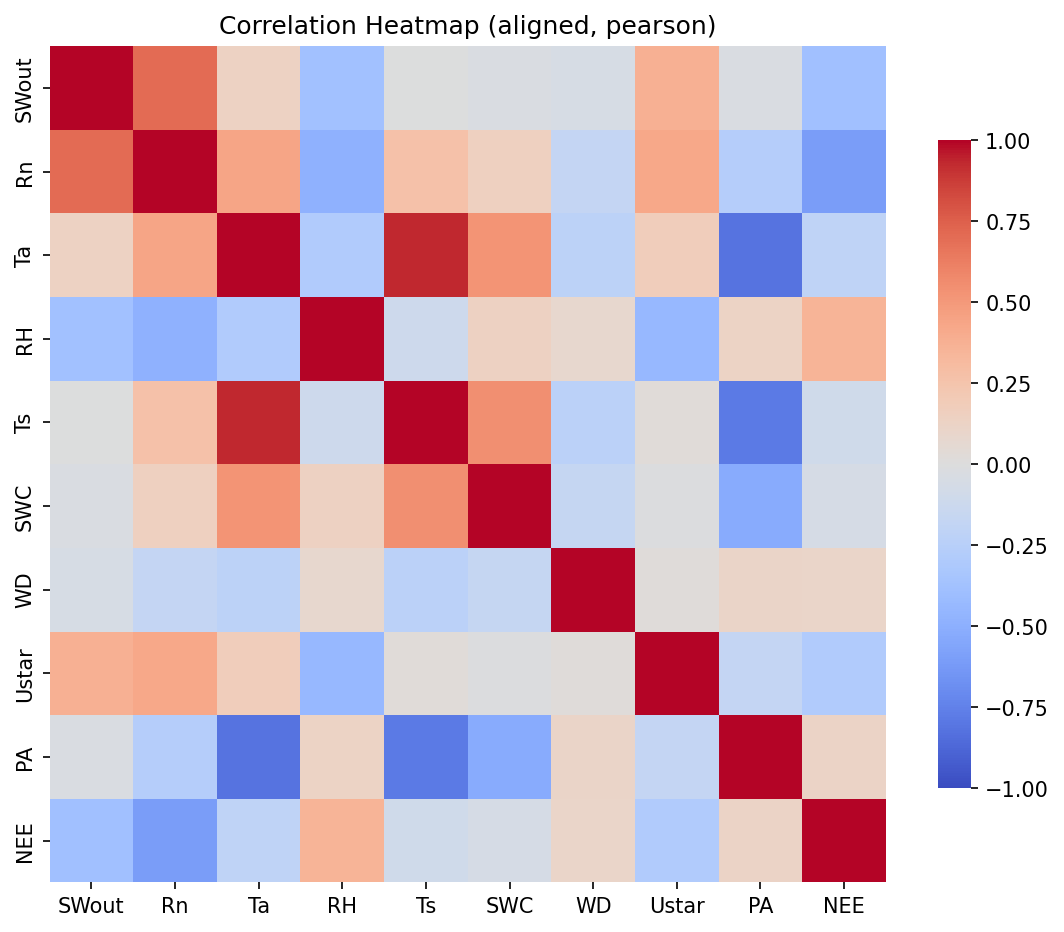


Top-20 绝对相关性:
Ta ~ Ts: corr=0.9362, |corr|=0.9362
Ta ~ PA: corr=-0.8161, |corr|=0.8161
Ts ~ PA: corr=-0.7888, |corr|=0.7888
SWout ~ Rn: corr=0.7032, |corr|=0.7032
Rn ~ NEE: corr=-0.6040, |corr|=0.6040
Ts ~ SWC: corr=0.5539, |corr|=0.5539
SWC ~ PA: corr=-0.5277, |corr|=0.5277
Ta ~ SWC: corr=0.5246, |corr|=0.5246
Rn ~ RH: corr=-0.4862, |corr|=0.4862
Rn ~ Ta: corr=0.4424, |corr|=0.4424
RH ~ Ustar: corr=-0.4421, |corr|=0.4421
Rn ~ Ustar: corr=0.4257, |corr|=0.4257
SWout ~ NEE: corr=-0.3881, |corr|=0.3881
SWout ~ RH: corr=-0.3804, |corr|=0.3804
SWout ~ Ustar: corr=0.3771, |corr|=0.3771
RH ~ NEE: corr=0.3553, |corr|=0.3553
Ta ~ RH: corr=-0.2941, |corr|=0.2941
Ustar ~ NEE: corr=-0.2893, |corr|=0.2893
Rn ~ Ts: corr=0.2699, |corr|=0.2699
Rn ~ PA: corr=-0.2658, |corr|=0.2658


In [12]:
# 列间相关性分析：自动选择对齐表(优先)或气象/通量表，计算并可视化
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = Path('.').resolve()
# 优先顺序：对齐表 → 气象表 → 通量表
paths = {
    'aligned': base_dir / '分析输出' / 'DuoLun_met_flux_aligned.csv',
    'met': base_dir / '分析输出' / 'DuoLun_merged.csv',
    'flux': base_dir / '分析输出' / 'DuoLun_flux_merged.csv',
}

# 选择数据集（可改为 'met' 或 'flux'）
dataset_choice = next((k for k,p in paths.items() if p.exists()), 'met')
path = paths[dataset_choice]
print('使用数据集:', dataset_choice, '\n文件:', path)

# 读取数据
try:
    df = pd.read_csv(path, parse_dates=['date'])
except Exception:
    df = pd.read_csv(path)

# 仅数值列参与相关性
num_df = df.select_dtypes(include=[np.number]).copy()
print('数值列数量:', num_df.shape[1])
assert num_df.shape[1] > 1, '数值列不足以计算相关性。'

# 相关性类型（可选 pearson/spearman）
method = 'pearson'
corr = num_df.corr(method=method)

# 导出CSV
out_dir = base_dir / '分析输出'
out_dir.mkdir(parents=True, exist_ok=True)
corr_csv = out_dir / f'corr_{dataset_choice}_{method}.csv'
corr.to_csv(corr_csv.as_posix())
print('已导出相关性矩阵 CSV:', corr_csv, 'shape=', corr.shape)

# 可视化热力图（根据列数自适应尺寸）
cols = list(num_df.columns)
w = min(0.35 * len(cols) + 4, 22)
h = min(0.35 * len(cols) + 4, 22)
plt.figure(figsize=(w, h), dpi=150)
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True,
            cbar_kws={'shrink': 0.6}, xticklabels=True, yticklabels=True)
plt.title(f'Correlation Heatmap ({dataset_choice}, {method})')
plt.tight_layout()

fig_path = out_dir / f'corr_heatmap_{dataset_choice}_{method}.png'
plt.savefig(fig_path.as_posix(), bbox_inches='tight')
print('已保存热力图:', fig_path)
plt.show()

# 打印绝对相关性Top-20（去除对角线与重复）
triu_idx = np.triu_indices_from(corr, k=1)
pairs = []
for i, j in zip(*triu_idx):
    pairs.append((corr.index[i], corr.columns[j], float(corr.values[i, j]), float(abs(corr.values[i, j]))))

pairs_sorted = sorted(pairs, key=lambda x: x[3], reverse=True)
print('\nTop-20 绝对相关性:')
for a, b, v, av in pairs_sorted[:20]:
    print(f'{a} ~ {b}: corr={v:.4f}, |corr|={av:.4f}')


In [15]:
# 导出最终数据：优先使用对齐后的结果，保存为 DuoLun.csv
import pandas as pd
import numpy as np
from pathlib import Path

base_dir = Path('.').resolve()
out_dir = base_dir / '分析输出'
out_dir.mkdir(parents=True, exist_ok=True)

aligned_csv = out_dir / 'DuoLun_met_flux_aligned.csv'
met_csv = out_dir / 'DuoLun_merged.csv'
flux_csv = out_dir / 'DuoLun_flux_merged.csv'

# 若已有对齐文件，直接读取；否则现场构建一次
if aligned_csv.exists():
    df = pd.read_csv(aligned_csv, parse_dates=['date'])
else:
    # 兜底构建：读取并按前述规则处理
    assert met_csv.exists() and flux_csv.exists(), '缺少中间CSV（气象/通量/对齐），请先运行上方单元生成。'
    met = pd.read_csv(met_csv, parse_dates=['date'])
    flux = pd.read_csv(flux_csv, parse_dates=['date'])
    # 移除气象表不需要的列
    cols_to_drop = ['SWin', 'LWin', 'LWout', 'G', 'PAR', 'Rainfall']
    met = met.drop(columns=[c for c in cols_to_drop if c in met.columns], errors='ignore')
    # 移除通量表的 LE/H
    flux = flux.drop(columns=[c for c in ['LE', 'H'] if c in flux.columns], errors='ignore')
    # 对齐
    df = pd.merge(met, flux, on='date', how='inner', suffixes=('_met', '_flux'))

# 最终再保险一次列清理
final_drop = ['SWin', 'LWin', 'LWout', 'G', 'PAR', 'Rainfall', 'LE', 'H', 'LE_flux', 'H_flux']
df = df.drop(columns=[c for c in final_drop if c in df.columns], errors='ignore')

# 统一将空白字符串视为缺失，去除包含空白/缺失的行
df = df.replace(r'^\s*$', np.nan, regex=True)
df = df.dropna(how='any').reset_index(drop=True)

# 过滤 NEE 列中以科学计数法表示的数值（含 'e' 或 'E' 的字符串/显示形式）
nee_candidates = ['NEE', 'NEE_flux', 'flux_NEE']
nee_col = next((c for c in nee_candidates if c in df.columns), None)
if nee_col is not None:
    before = len(df)
    mask_no_sci = ~df[nee_col].astype(str).str.contains(r'[eE]', na=False)
    df = df.loc[mask_no_sci].reset_index(drop=True)
    removed = before - len(df)
    if removed > 0:
        print(f'已移除 {removed} 行含科学计数法(含 e/E)的 {nee_col} 数据')

# 小数位控制：NEE 保留9位，其余数值列保留6位
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if nee_col and nee_col in num_cols:
    other_cols = [c for c in num_cols if c != nee_col]
    if other_cols:
        df[other_cols] = df[other_cols].round(6)
    df[nee_col] = df[nee_col].round(9)
else:
    if num_cols:
        df[num_cols] = df[num_cols].round(6)

# 排序并导出
df = df.sort_values('date').reset_index(drop=True)

final_path = out_dir / 'DuoLun.csv'
df.to_csv(final_path.as_posix(), index=False)
print('已导出最终数据到:', final_path, 'shape=', df.shape)

display(df.head(5))


已移除 1291 行含科学计数法(含 e/E)的 NEE 数据
已导出最终数据到: /sda/home/wangmengyao/timexer/data_process/多伦/分析输出/DuoLun.csv shape= (166606, 12)


,date,SWout,Rn,Ta,RH,Ts,SWC,WS,WD,Ustar,PA,NEE
0,2006-01-01 00:00:00,0.838569,-87.2177,-9.52959,76.4537,-7.729,0.038,4.96801,312.374,0.389470,85.6218,0.005543
1,2006-01-01 00:30:00,1.037520,-86.2181,-9.55552,75.5225,-7.802,0.038,4.56082,322.732,0.329278,85.6334,0.011973
2,2006-01-01 01:00:00,0.964466,-85.7744,-9.76438,74.7686,-7.879,0.038,4.54027,319.055,0.321958,85.6444,0.019363
3,2006-01-01 01:30:00,0.686394,-86.1669,-10.65380,76.2375,-7.961,0.038,4.86875,310.059,0.322772,85.6402,0.015838
4,2006-01-01 02:00:00,0.195798,-77.8439,-12.44440,78.8450,-8.050,0.038,2.75684,288.643,0.293658,85.6722,0.009041
